# Exam Score Prediction — Analysis Notebook

This notebook walks through the project step by step: understanding the data, preprocessing, training Linear Regression, comparing it with four other models, and predicting for new students.

The reusable code lives in `src/`; this notebook imports it so the notebook and the scripts always agree.

In [1]:
import sys, json
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src import config
from src.preprocess import load_raw_data, clean_data, split_data, build_preprocessor
from src.evaluate import regression_metrics, linear_coefficients

pd.set_option('display.max_columns', 30)

## 1. Load and understand the dataset

In [2]:
raw = load_raw_data()
print('Shape:', raw.shape)
raw.head()

Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
raw.dtypes.to_frame('dtype').T

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
dtype,int64,int64,object,object,object,int64,int64,object,object,int64,object,object,object,object,int64,object,object,object,object,int64


In [4]:
raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.98,5.99,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.98,11.55,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.03,1.47,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.07,14.40,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.49,1.23,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.97,1.03,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.24,3.89,55.0,65.0,67.0,69.0,101.0


### Data quality checks
Missing values, duplicates and impossible target values.

In [5]:
missing = raw.isna().sum()
print('Missing values:')
print(missing[missing > 0])
print()
print('Duplicate rows:', raw.duplicated().sum())
print('Exam scores outside 0-100:', (~raw[config.TARGET].between(0, 100)).sum())
raw[raw[config.TARGET] > 100]

Missing values:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Duplicate rows: 0
Exam scores outside 0-100: 1


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


Three categorical columns have a small number of missing values (about 1% each). One record has an exam score of 101, which is impossible for a percentage, so it is removed. There are no duplicate rows.

In [6]:
for col in list(config.ORDINAL_FEATURES) + list(config.BINARY_FEATURES):
    print(f'{col:<28}', raw[col].value_counts(dropna=False).to_dict())

Parental_Involvement         {'Medium': 3362, 'High': 1908, 'Low': 1337}
Access_to_Resources          {'Medium': 3319, 'High': 1975, 'Low': 1313}
Motivation_Level             {'Medium': 3351, 'Low': 1937, 'High': 1319}
Family_Income                {'Low': 2672, 'Medium': 2666, 'High': 1269}
Teacher_Quality              {'Medium': 3925, 'High': 1947, 'Low': 657, nan: 78}
Peer_Influence               {'Positive': 2638, 'Neutral': 2592, 'Negative': 1377}
Parental_Education_Level     {'High School': 3223, 'College': 1989, 'Postgraduate': 1305, nan: 90}
Distance_from_Home           {'Near': 3884, 'Moderate': 1998, 'Far': 658, nan: 67}
Extracurricular_Activities   {'Yes': 3938, 'No': 2669}
Internet_Access              {'Yes': 6108, 'No': 499}
School_Type                  {'Public': 4598, 'Private': 2009}
Learning_Disabilities        {'No': 5912, 'Yes': 695}
Gender                       {'Male': 3814, 'Female': 2793}


## 2. Exploratory data analysis
The graphs are produced by `src/visualize.py` and saved in `graphs/`.

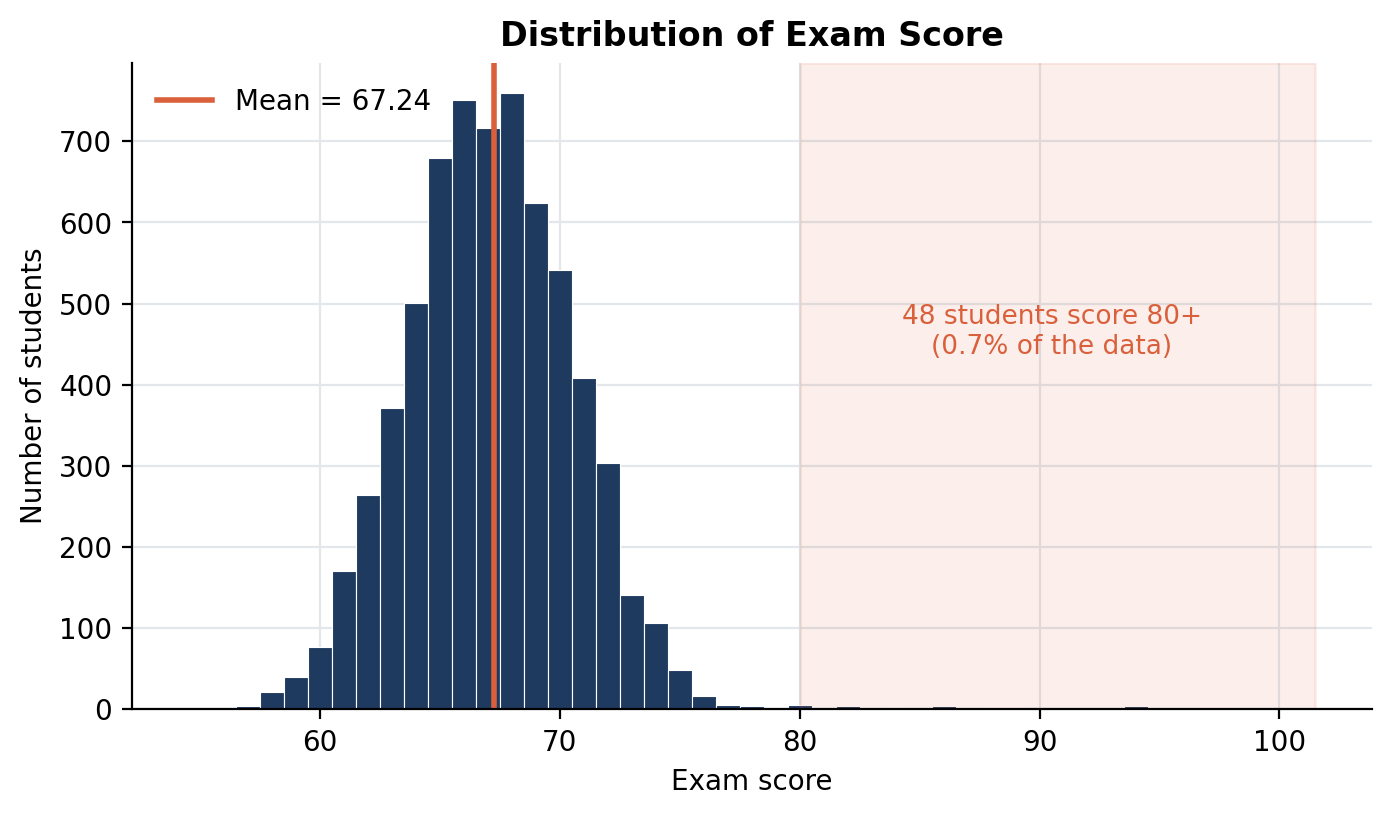

In [7]:
display(Image('../graphs/01_exam_score_distribution.png', width=700))

Most students score between 60 and 75. A thin tail of about 1% of students scores 80 or more; these few records turn out to matter a lot for the error metrics later.

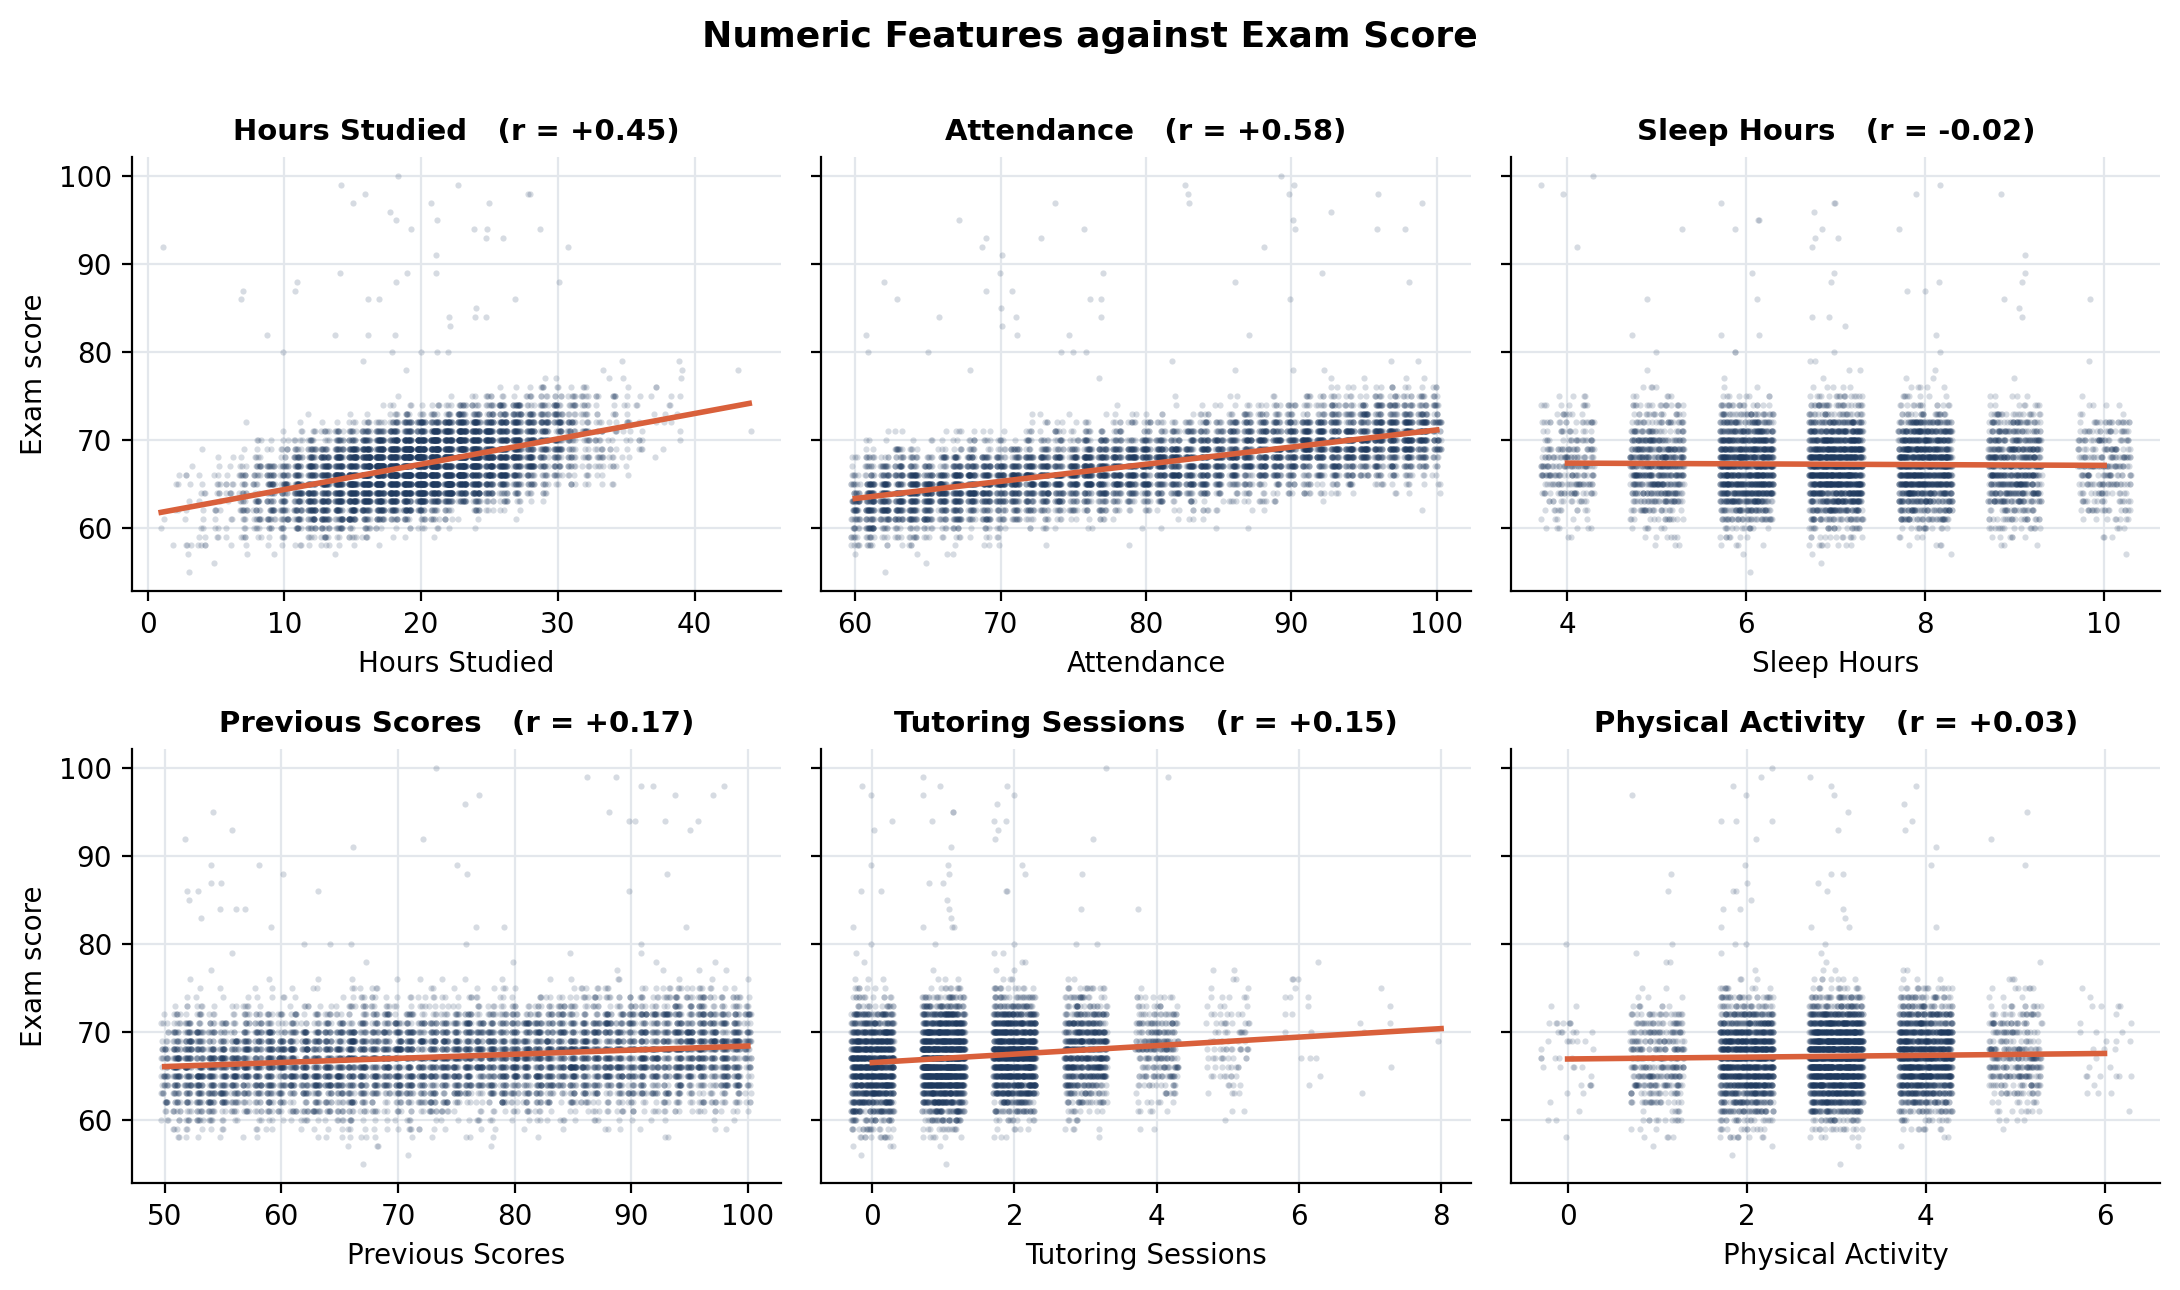

In [8]:
display(Image('../graphs/03_numeric_vs_exam_score.png', width=900))

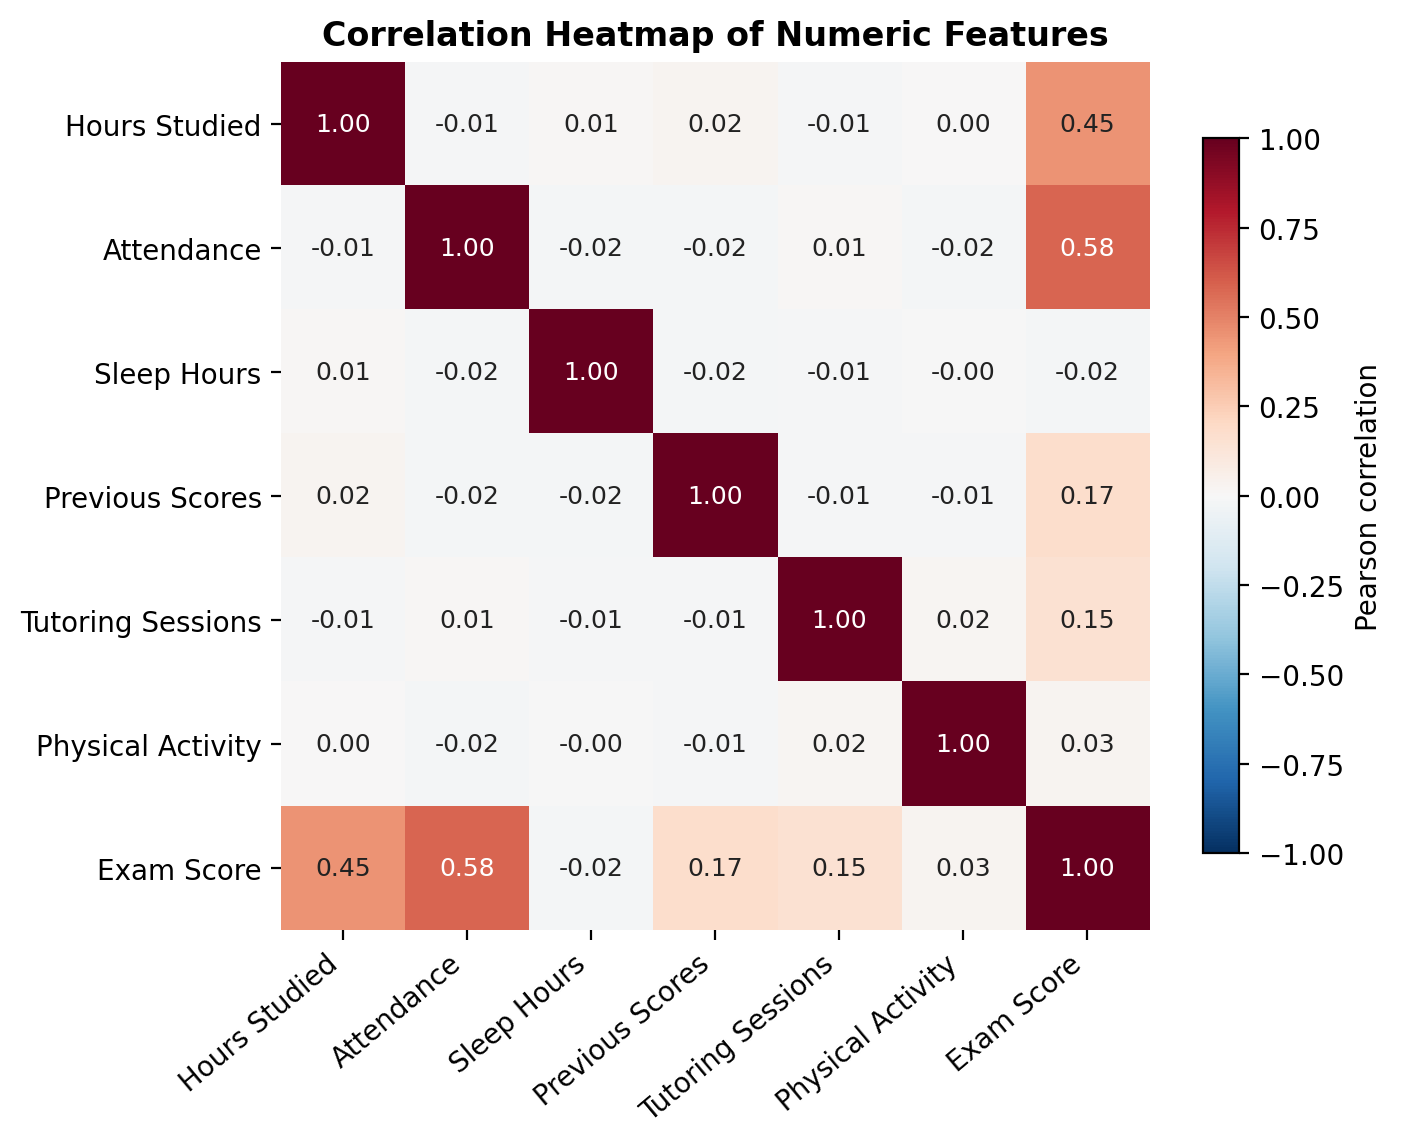

In [9]:
display(Image('../graphs/04_correlation_heatmap.png', width=600))

`Attendance` (r = 0.58) and `Hours_Studied` (r = 0.45) have the strongest linear relationship with the exam score. `Previous_Scores` is much weaker (r = 0.18), and `Sleep_Hours` shows no relationship. The input features are almost uncorrelated with each other, so multicollinearity is not a concern for Linear Regression.

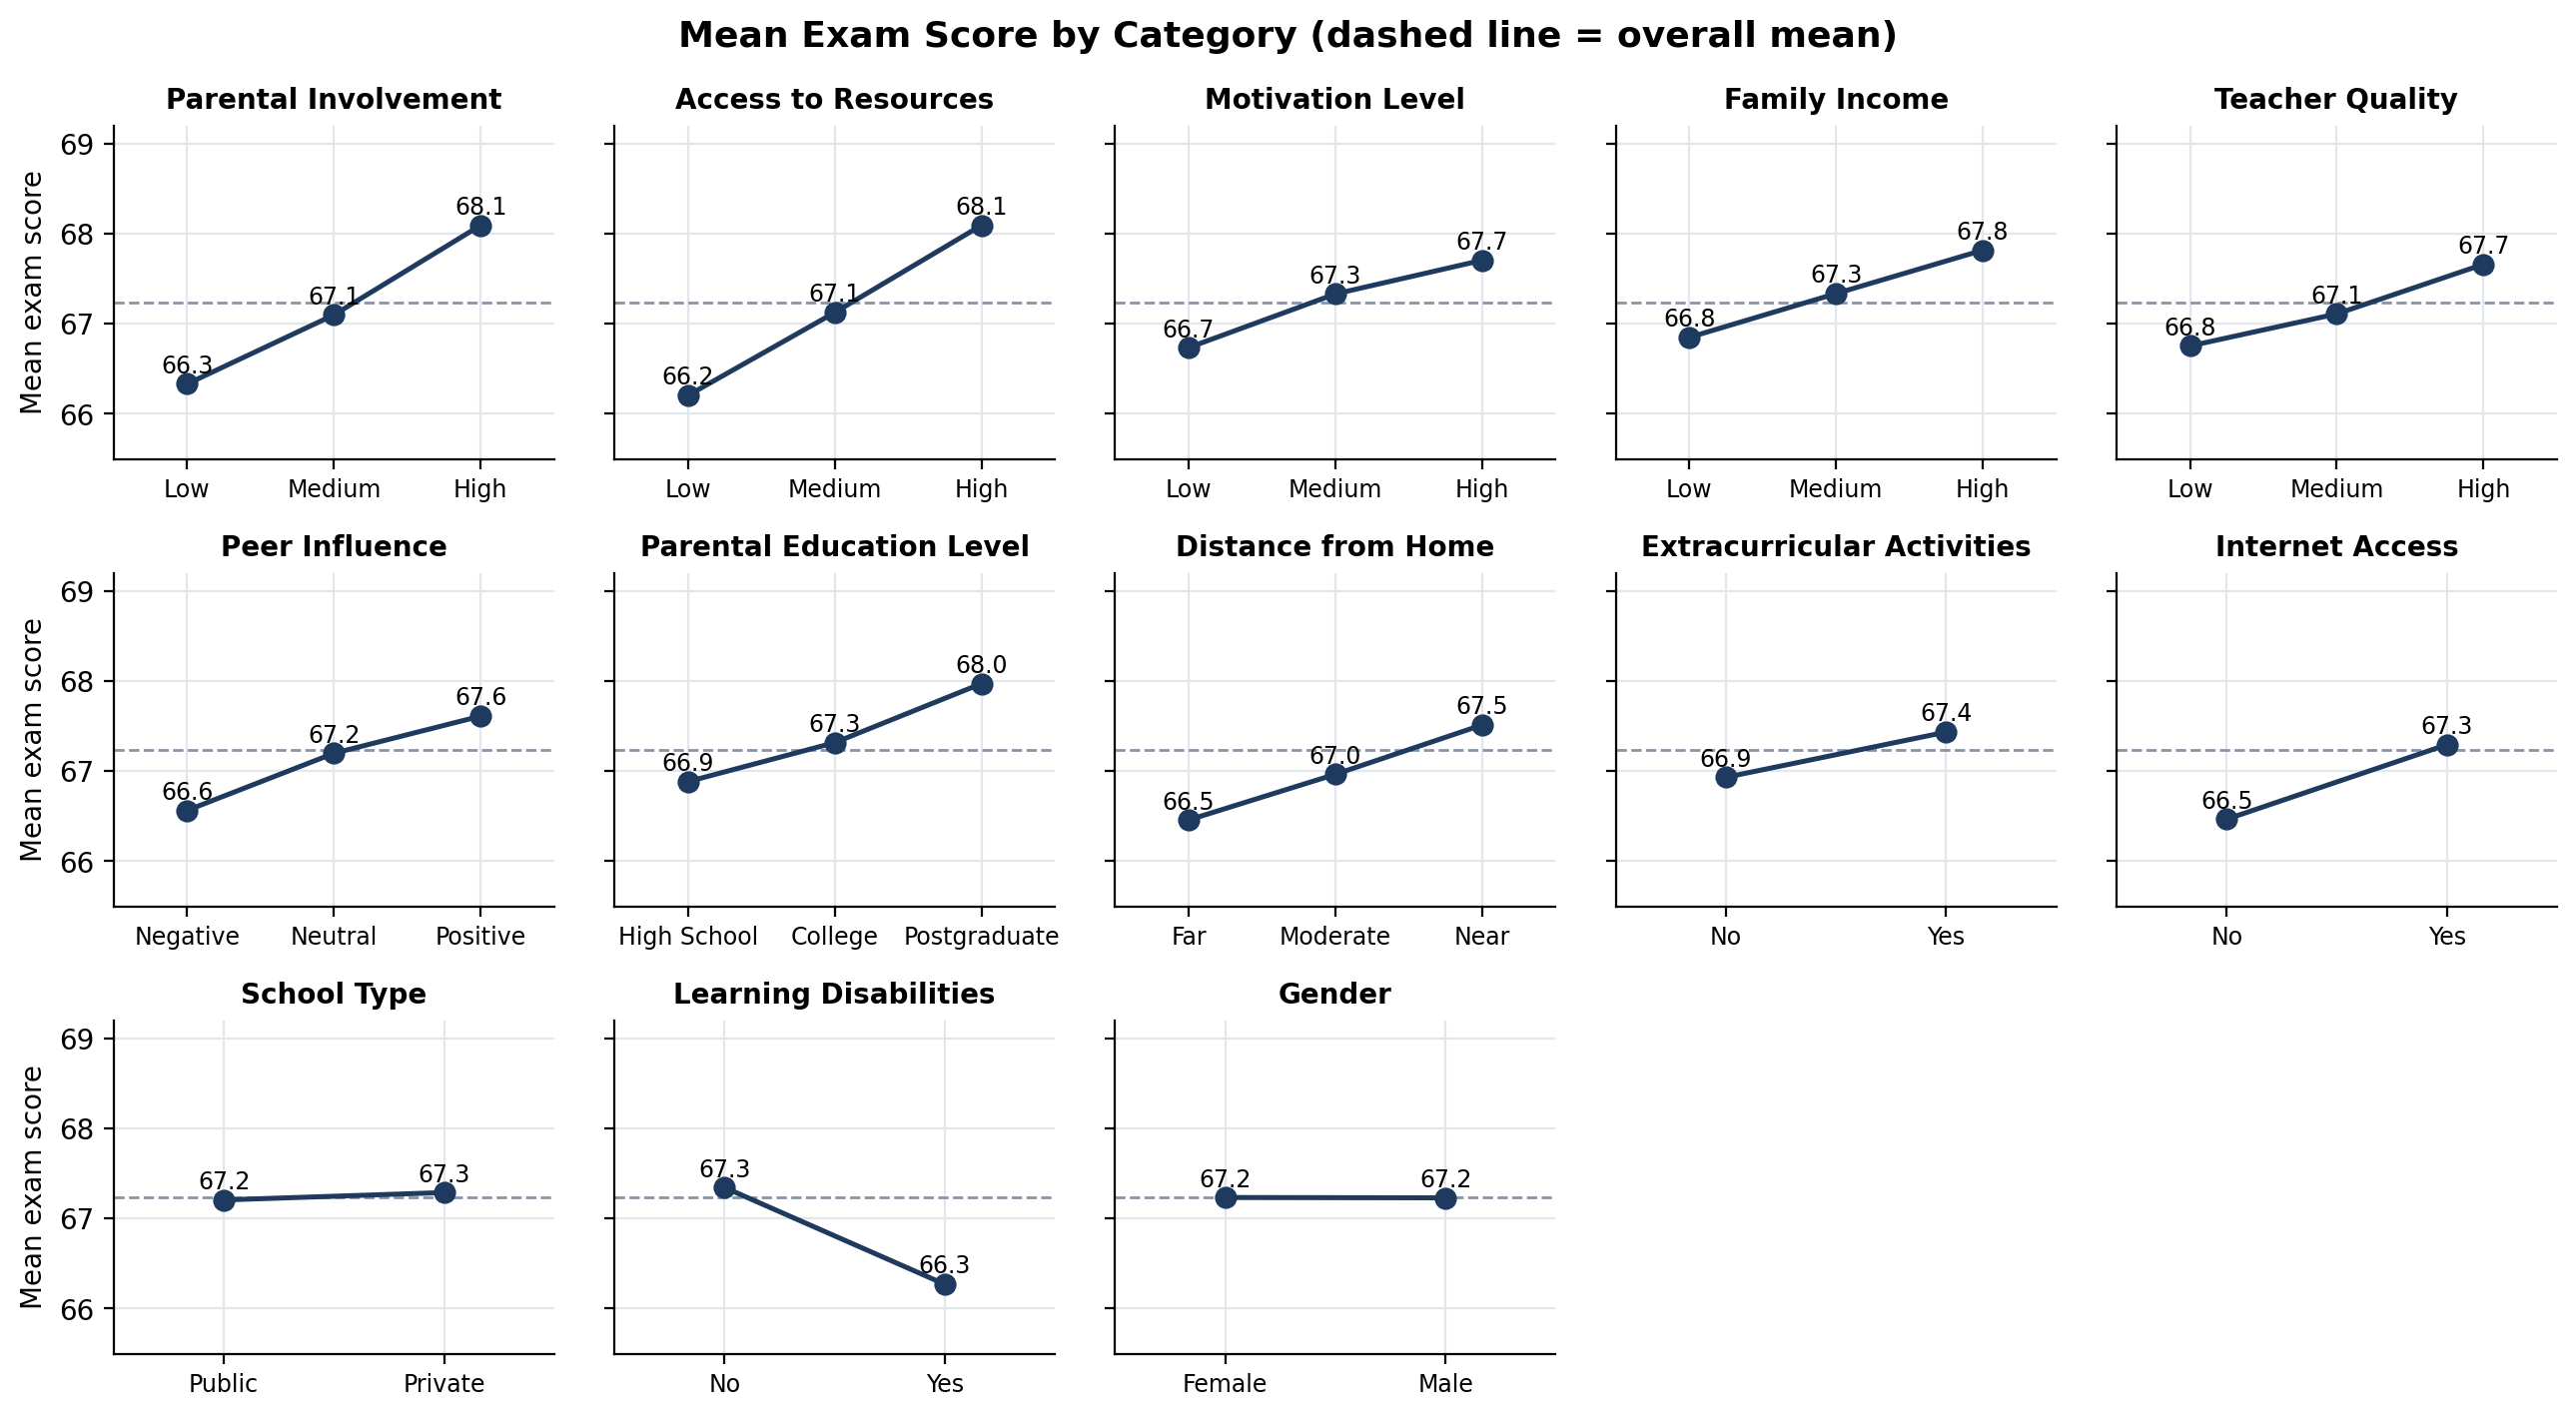

In [10]:
display(Image('../graphs/05_categorical_vs_exam_score.png', width=950))

## 3. Cleaning and train/test split

In [11]:
df, log = clean_data(raw)
print(json.dumps(log, indent=2))
X_train, X_test, y_train, y_test = split_data(df)
print('Train:', X_train.shape, ' Test:', X_test.shape)

{
  "rows_before": 6607,
  "duplicates_removed": 0,
  "invalid_target_removed": 1,
  "rows_after": 6606,
  "missing_values": {
    "Teacher_Quality": 78,
    "Parental_Education_Level": 90,
    "Distance_from_Home": 67
  }
}
Train: (5284, 19)  Test: (1322, 19)


## 4. Preprocessing pipeline

- **Numeric features**: median imputation, then standardisation.
- **Ordinal features** (Low/Medium/High and similar): most-frequent imputation, then encoded as 0/1/2 in their natural order.
- **Binary features**: most-frequent imputation, then a single 0/1 column.

The preprocessor sits inside the model pipeline, so it is fitted on the training split only and the test set cannot leak into it.

In [12]:
pre = build_preprocessor()
Xt = pre.fit_transform(X_train)
pd.DataFrame(Xt, columns=pre.get_feature_names_out()).head().round(3)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement,Access_to_Resources,Motivation_Level,Family_Income,Teacher_Quality,Peer_Influence,Parental_Education_Level,Distance_from_Home,Extracurricular_Activities_Yes,Internet_Access_Yes,School_Type_Private,Learning_Disabilities_Yes,Gender_Male
0,-1.510,-0.433,1.346,0.137,-0.398,-0.945,2.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
1,-2.013,-0.607,0.665,0.206,-1.210,0.026,1.0,2.0,2.0,1.0,2.0,0.0,0.0,2.0,0.0,1.0,1.0,0.0,1.0
2,-1.677,-0.346,-2.056,-0.490,-0.398,2.939,1.0,0.0,1.0,2.0,0.0,1.0,1.0,2.0,0.0,1.0,1.0,0.0,1.0
3,-0.002,0.347,-0.015,-0.072,-0.398,0.026,0.0,0.0,0.0,2.0,1.0,1.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0
4,-0.002,-1.560,-2.056,1.599,-0.398,0.997,1.0,1.0,2.0,2.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0


## 5. Train Linear Regression

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

linreg = Pipeline([('preprocess', build_preprocessor()), ('model', LinearRegression())])
linreg.fit(X_train, y_train)

print('Train:', {k: round(v, 4) for k, v in regression_metrics(y_train, linreg.predict(X_train)).items()})
print('Test: ', {k: round(v, 4) for k, v in regression_metrics(y_test, linreg.predict(X_test)).items()})

Train: {'MAE': 0.4996, 'MSE': 4.4532, 'RMSE': 2.1103, 'R2': 0.7107}
Test:  {'MAE': 0.4103, 'MSE': 2.3038, 'RMSE': 1.5178, 'R2': 0.8258}


### What the model learned
`Marks_Per_Unit` is the change in predicted marks for one unit of the feature (one extra hour, one percentage point of attendance, one step up from Low to Medium, and so on).

In [14]:
print('Intercept:', round(linreg.named_steps['model'].intercept_, 3))
linear_coefficients(linreg).round(4)

Intercept: 60.758


,Feature,Type,Model_Coefficient,Marks_Per_Unit
0,Attendance,numeric,2.2846,0.1981
1,Hours_Studied,numeric,1.7430,0.2921
2,Access_to_Resources,ordinal,1.0463,1.0463
3,Parental_Involvement,ordinal,1.0158,1.0158
4,Internet_Access,binary,0.9473,0.9473
5,Learning_Disabilities,binary,-0.8851,-0.8851
6,Previous_Scores,numeric,0.7039,0.0490
7,Tutoring_Sessions,numeric,0.5952,0.4828
8,Extracurricular_Activities,binary,0.5502,0.5502
9,Motivation_Level,ordinal,0.5402,0.5402


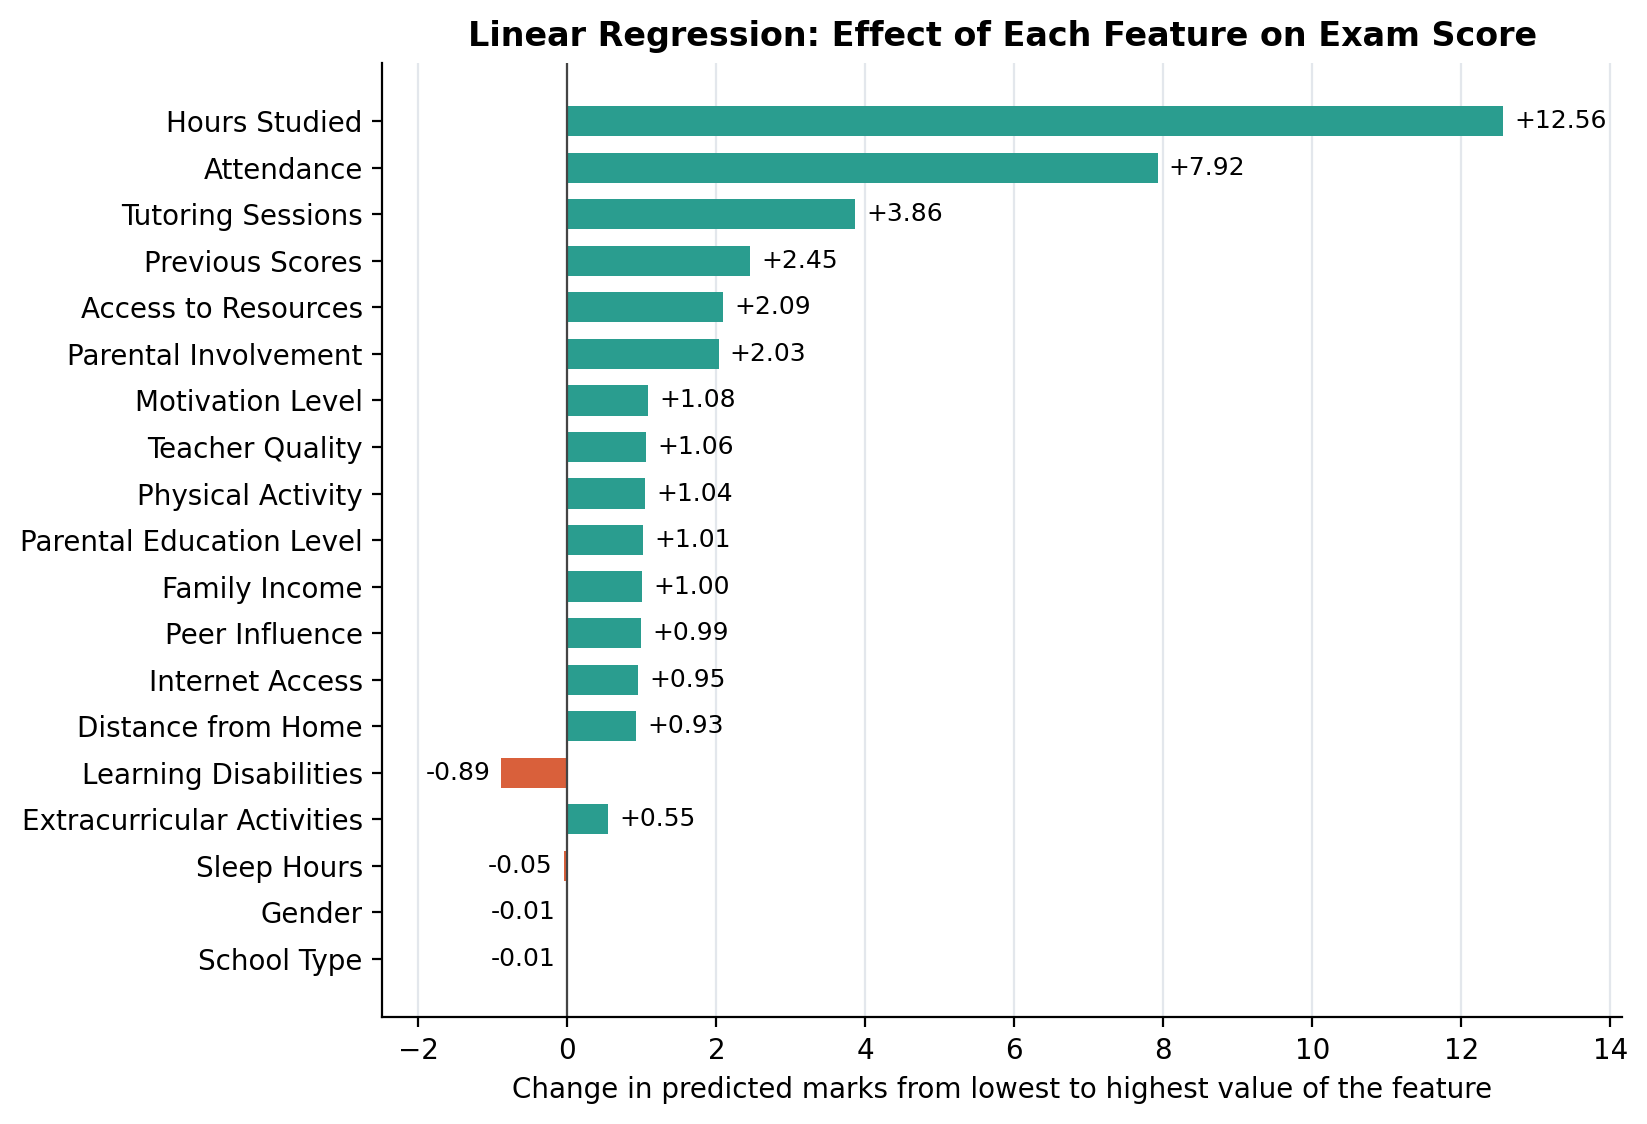

In [15]:
display(Image('../graphs/09_feature_effects.png', width=700))

## 6. Compare with other models
`python -m src.train` tunes each model with 5-fold cross-validation on the training set and evaluates all of them on the same test set.

In [16]:
comparison = pd.read_csv('../results/model_comparison.csv')
comparison.round(4)

,Model,Best_Params,CV_R2_Mean,CV_R2_Std,Train_R2,Test_MAE,Test_MSE,Test_RMSE,Test_R2
0,Linear Regression,default,0.7171,0.0731,0.7107,0.4103,2.3038,1.5178,0.8258
1,Ridge Regression,"{""alpha"": 10}",0.7171,0.0731,0.7107,0.4112,2.3041,1.5179,0.8258
2,Lasso Regression,"{""alpha"": 0.001}",0.7171,0.0731,0.7107,0.4108,2.3043,1.5180,0.8258
3,Decision Tree,"{""max_depth"": 10, ""min_samples_leaf"": 20}",0.5290,0.0396,0.6470,1.4463,5.2816,2.2982,0.6006
4,Random Forest,"{""max_depth"": null, ""min_samples_leaf"": 3}",0.6356,0.0605,0.8305,1.0086,3.5592,1.8866,0.7309


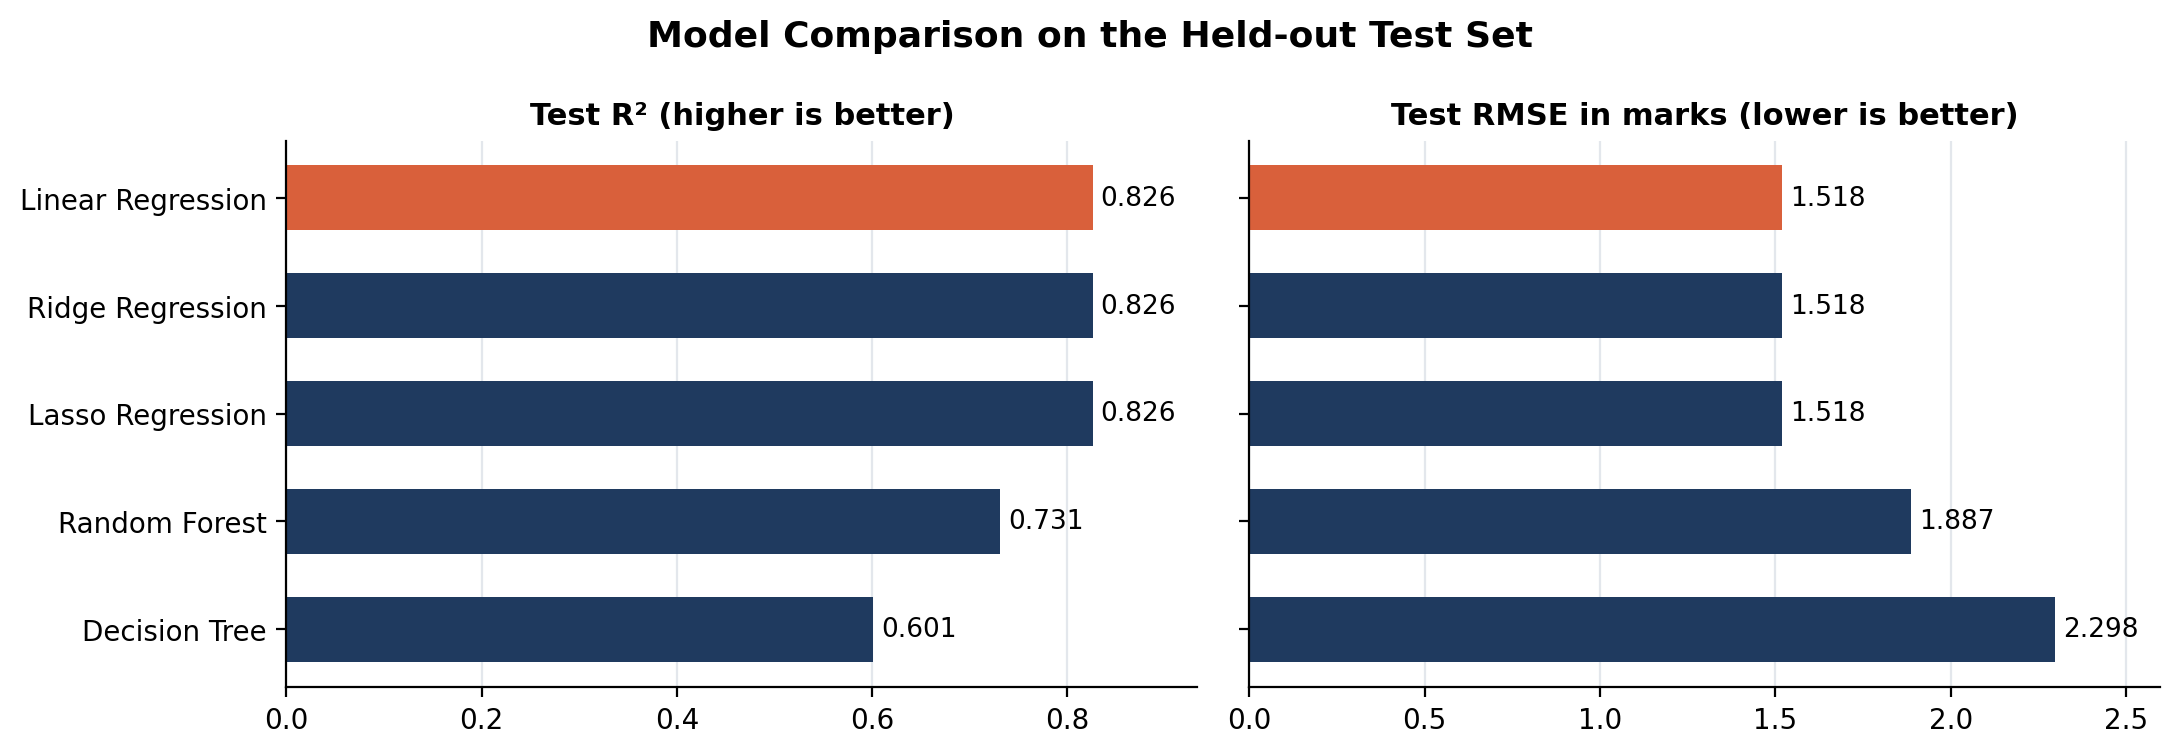

In [17]:
display(Image('../graphs/06_model_comparison.png', width=900))

Linear Regression, Ridge and Lasso are practically identical and clearly better than the tree-based models. The relationship in this dataset is additive and linear, which is exactly what a linear model represents and what trees can only approximate with many splits.

## 7. Error analysis

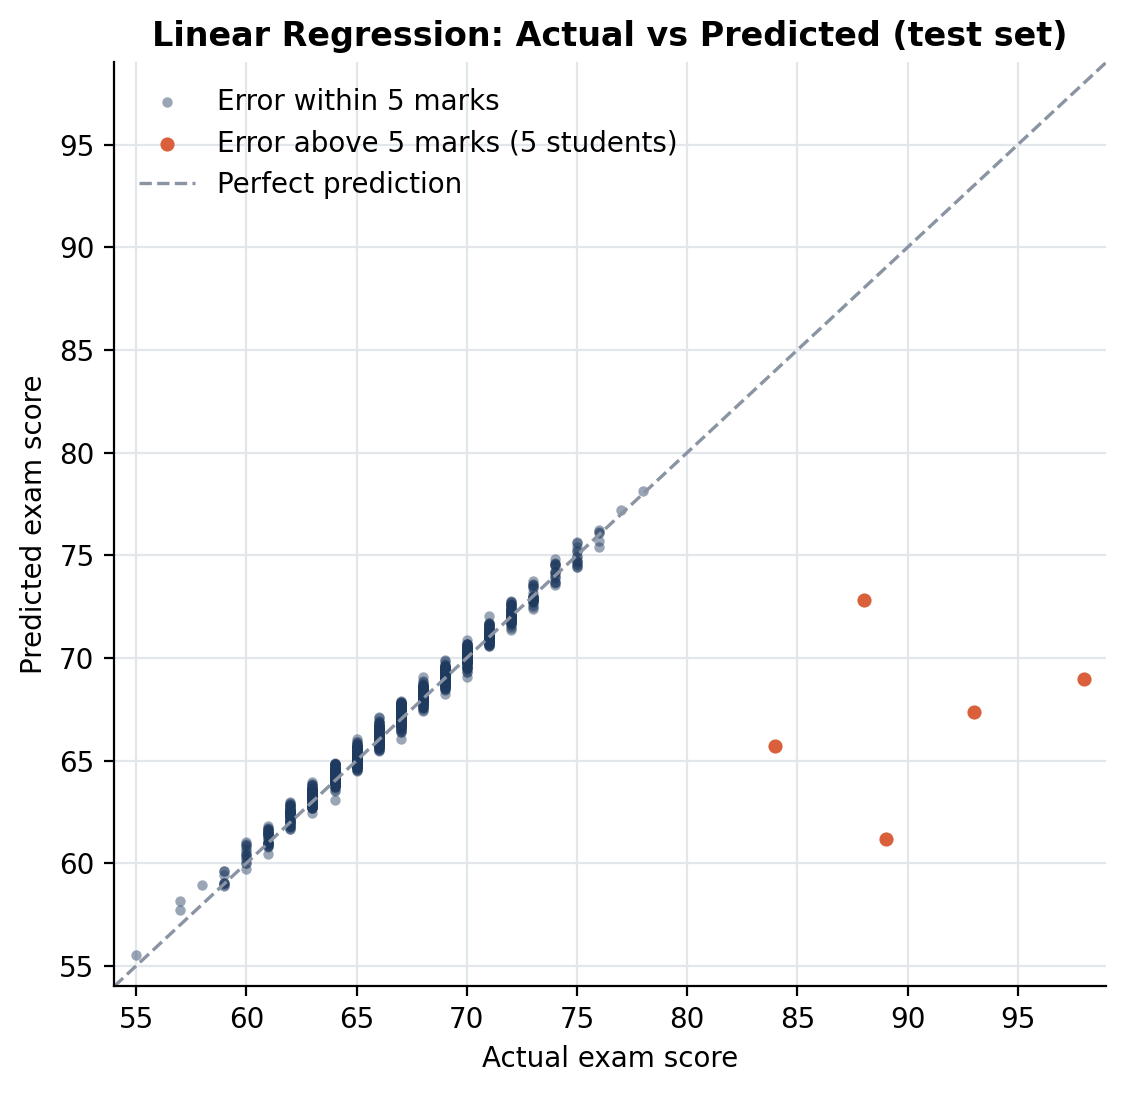

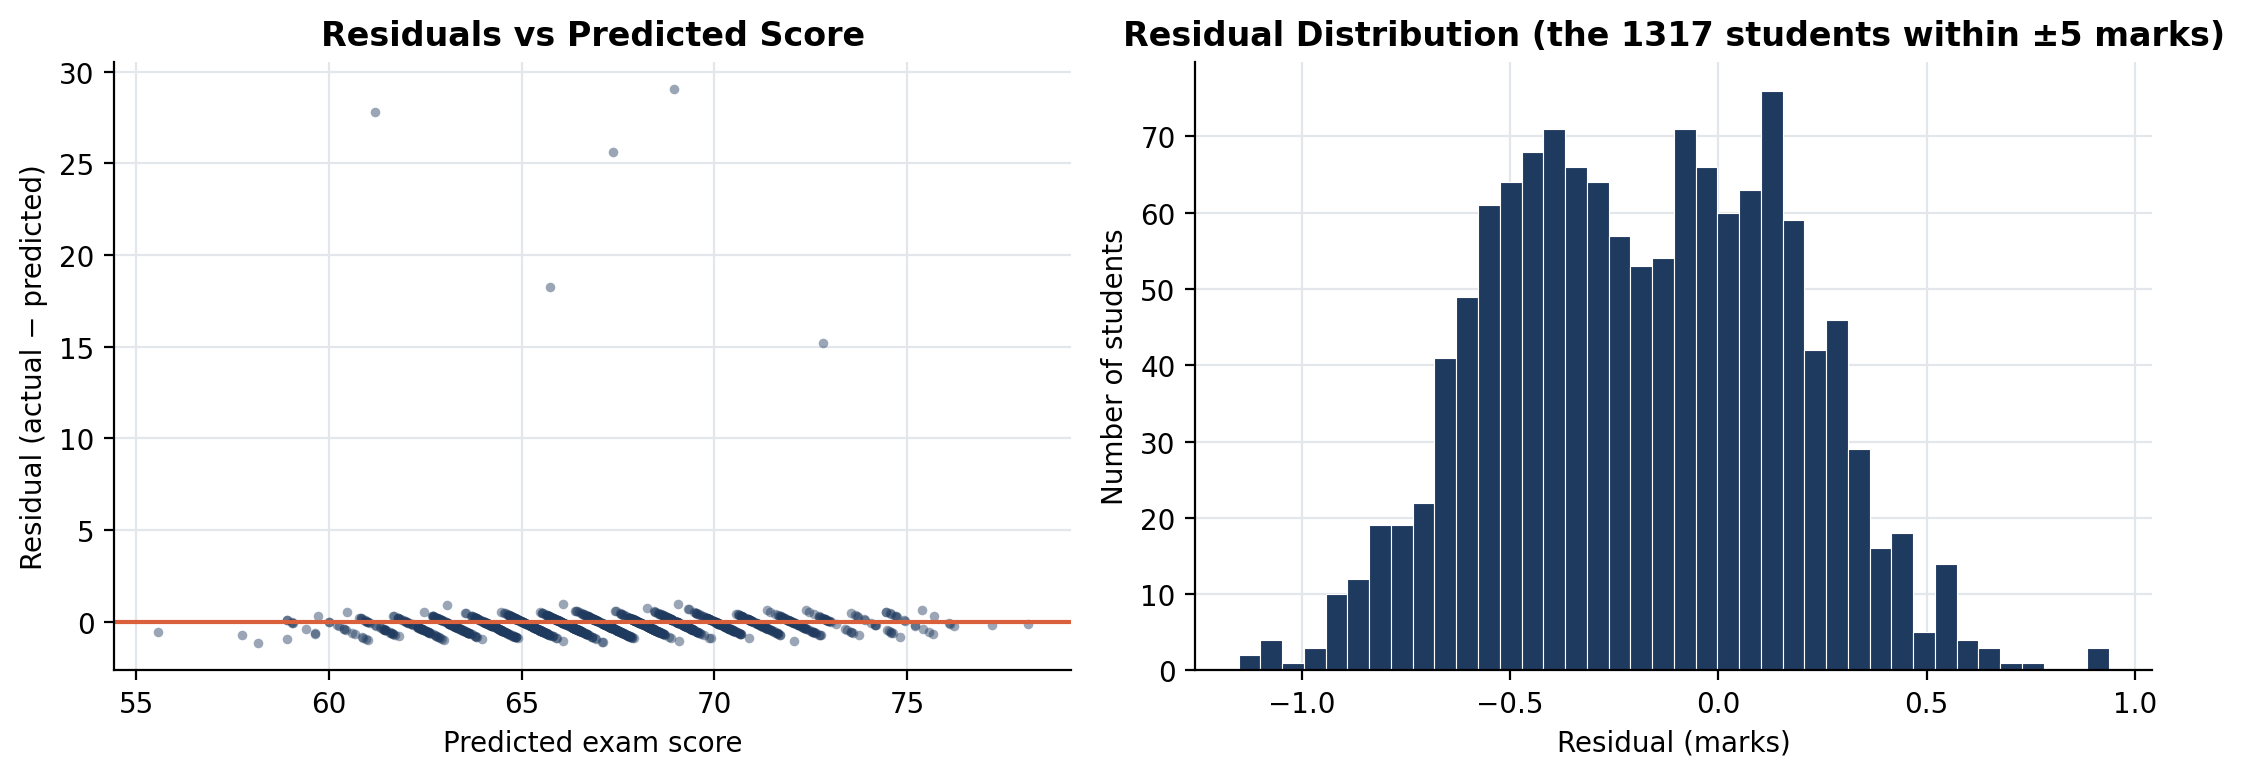

In [18]:
display(Image('../graphs/07_actual_vs_predicted.png', width=520))
display(Image('../graphs/08_residual_analysis.png', width=900))

In [19]:
print(json.dumps(json.load(open('../results/error_analysis.json'))['residuals'], indent=2))

{
  "test_rows": 1322,
  "test_errors_above_5": 5,
  "test_share_within_1_mark": 0.9909228441754917,
  "test_share_within_2_marks": 0.9962178517397882,
  "test_mae_excluding_large_errors": 0.3237994600513368,
  "test_rmse_excluding_large_errors": 0.3966652912142066,
  "test_largest_error": 29.04201763344929,
  "train_rows": 5284,
  "train_errors_above_5": 44,
  "train_largest_error": 29.93951942586247
}


About 99% of test predictions are within one mark of the true score. Only 5 of the 1,322 test students have an error above 5 marks, but those errors are so large (up to 29 marks) that they account for most of the RMSE. These are the high-scoring students seen in the tail of the distribution: nothing in their input features explains their scores, so no model can predict them.

This also explains why the test R² (0.826) is higher than the training R² (0.711): the training split happens to contain proportionally more of these unpredictable records.

## 8. Feature study

,Feature_Set,Test_MAE,Test_RMSE,Test_R2
0,Previous_Scores only,2.6951,3.5653,0.0388
1,Previous_Scores + Hours_Studied + Attendance,1.3296,2.1346,0.6554
2,All numeric features (6),1.2442,2.0432,0.6843
3,All features (19),0.4103,1.5178,0.8258


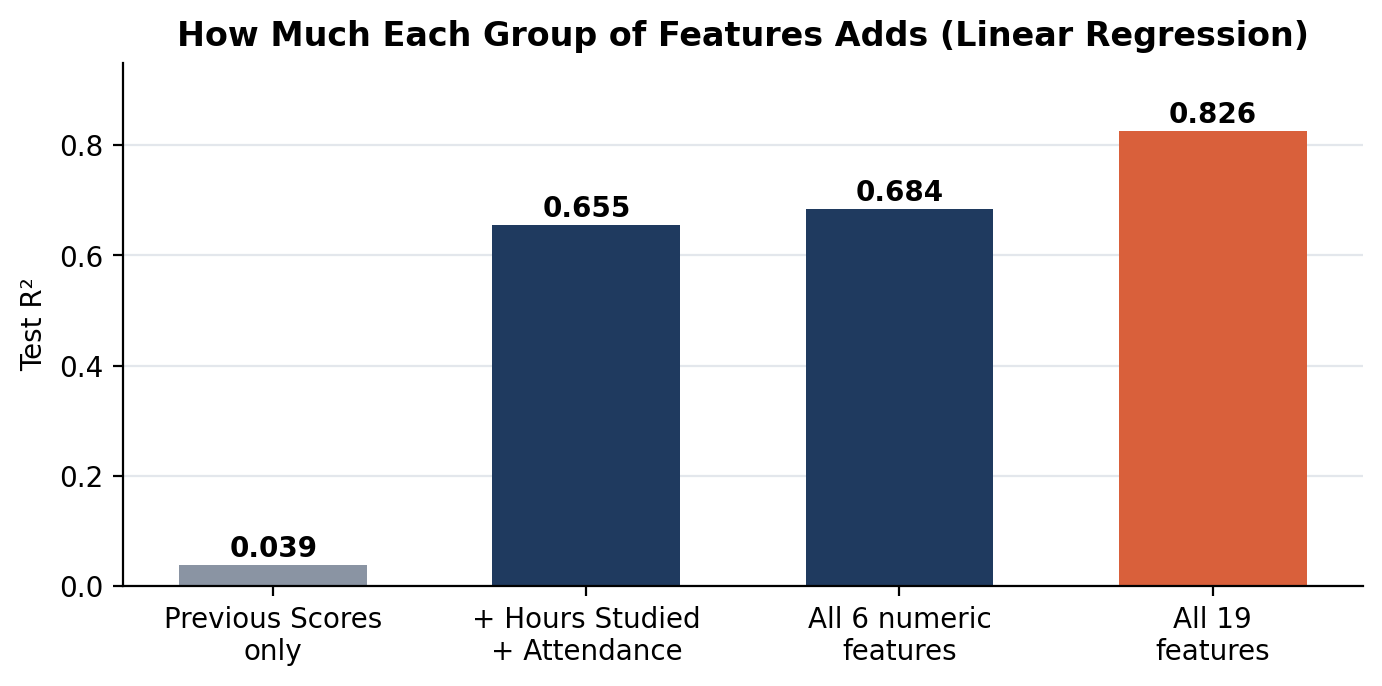

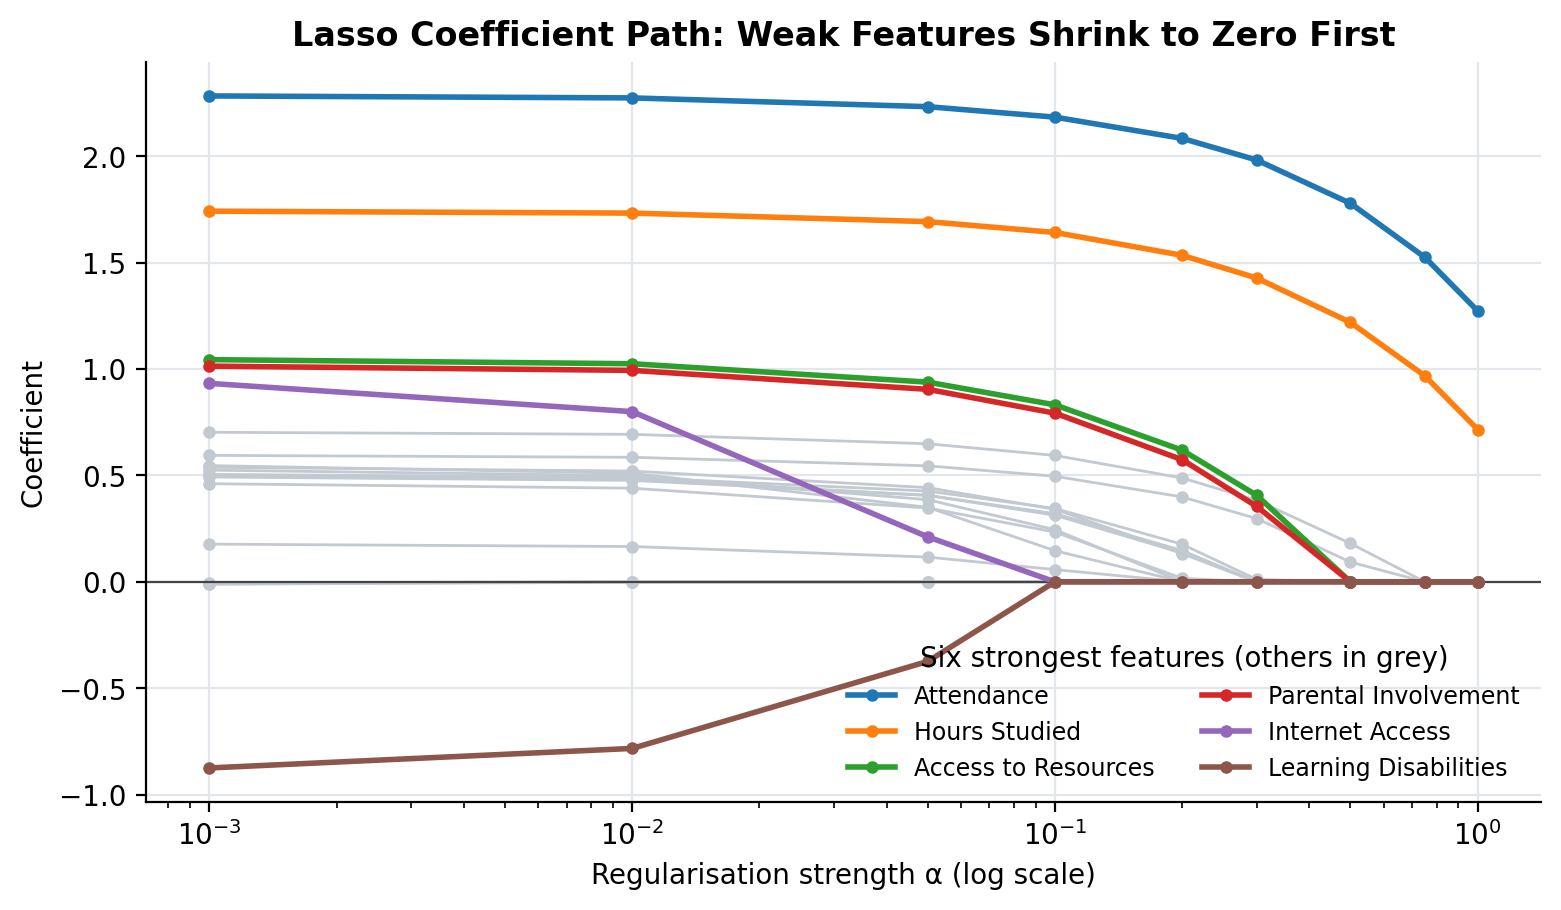

In [20]:
display(pd.read_csv('../results/feature_ablation.csv').round(4))
display(Image('../graphs/10_feature_ablation.png', width=700))
display(Image('../graphs/11_lasso_coefficient_path.png', width=750))

Previous scores alone explain under 4% of the variation. Adding study hours and attendance lifts R² to 0.66, and the full set of 19 features reaches 0.83. Lasso removes `Gender`, `School_Type` and `Sleep_Hours` first, confirming they carry almost no information.

## 9. Prediction on new data

In [21]:
from src.predict import load_model, predict_score, NEW_STUDENTS

model = load_model()
rows = [{**s, 'Predicted_Exam_Score': round(predict_score(model, s), 2)} for s in NEW_STUDENTS]
pd.DataFrame(rows)[['Profile', 'Hours_Studied', 'Attendance', 'Previous_Scores', 'Motivation_Level', 'Predicted_Exam_Score']]

,Profile,Hours_Studied,Attendance,Previous_Scores,Motivation_Level,Predicted_Exam_Score
0,Struggling student,8,62,55,Low,51.29
1,Average student,20,80,75,Medium,67.11
2,High-effort student,34,97,92,High,82.10


## 10. Conclusion

Linear Regression is the best-performing model on this dataset (test R² = 0.826, MAE = 0.41 marks). The most influential factors are hours studied and attendance. The saved pipeline in `models/exam_score_model.pkl` is served by the FastAPI backend (`backend/main.py`) to the React web application.